# 05 — ML: Classificação com Random Forest
**Projeto: Data Science dos Santos Católicos**

**Pergunta:** *Conseguimos prever se um santo é mártir com base nos dados históricos?*

**Pipeline:**
1. Baseline simples → Regressão Logística → **Random Forest**
2. Avaliação: matriz de confusão, ROC curve, precision-recall
3. **Feature Importance** — quais variáveis mais importam?
4. Validação cruzada
5. Interpretabilidade com SHAP (opcional)

## Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

PROJECT_ROOT = Path(os.getcwd()).parent
DATA_PROC    = PROJECT_ROOT / 'data' / 'processed'
FIGS         = PROJECT_ROOT / 'outputs' / 'figures'
MODELS       = PROJECT_ROOT / 'outputs' / 'models'

plt.rcParams.update({'figure.dpi': 120, 'font.size': 12,
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_theme(style='whitegrid')

df = pd.read_csv(DATA_PROC / 'saints_clean.csv')
print(f'Dataset: {df.shape}')

Dataset: (77, 19)


## 1. Preparar Dados

In [2]:
# Target: is_martyr (0 = não mártir, 1 = mártir)
df_ml = df.copy()
df_ml['is_martyr'] = df_ml['is_martyr'].fillna(False).astype(int)

# Features
features = ['death_year', 'century_of_death', 'years_to_canonization',
            'num_patron_topics', 'feast_month', 'is_doctor', 'is_virgin']
features = [f for f in features if f in df_ml.columns]

# Codificar continente
le = LabelEncoder()
if 'continent' in df_ml.columns:
    df_ml['continent_enc'] = le.fit_transform(df_ml['continent'].fillna('Unknown'))
    features.append('continent_enc')

# Codificar gênero
if 'gender' in df_ml.columns:
    df_ml['gender_enc'] = (df_ml['gender'] == 'F').astype(int)
    features.append('gender_enc')

# Remover nulos
df_ml = df_ml[features + ['is_martyr', 'name']].dropna(subset=['death_year'])
df_ml[features] = df_ml[features].fillna(df_ml[features].median())
df_ml[features] = df_ml[features].apply(pd.to_numeric, errors='coerce').fillna(0)

X = df_ml[features].values
y = df_ml['is_martyr'].values

print(f'Amostras: {len(X)}')
print(f'Features: {features}')
print(f'Mártires: {y.sum()} ({y.mean():.1%})')
print(f'Não-mártires: {(1-y).sum()} ({(1-y).mean():.1%})')

Amostras: 77
Features: ['death_year', 'century_of_death', 'years_to_canonization', 'num_patron_topics', 'feast_month', 'is_doctor', 'is_virgin', 'continent_enc', 'gender_enc']
Mártires: 16 (20.8%)
Não-mártires: 61 (79.2%)


In [3]:
# Dividir treino/teste (estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalizar
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Treino: {X_train.shape}  |  Teste: {X_test.shape}')

Treino: (61, 9)  |  Teste: (16, 9)


## 2. Treinar Modelos

In [4]:
modelos = {
    'Baseline (Dummy)':       DummyClassifier(strategy='most_frequent', random_state=42),
    'Regressão Logística':    LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':          RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}

resultados = []
modelos_treinados = {}

for nome, modelo in modelos.items():
    X_tr = X_train_sc if nome != 'Random Forest' else X_train
    X_ts = X_test_sc  if nome != 'Random Forest' else X_test

    modelo.fit(X_tr, y_train)
    y_pred = modelo.predict(X_ts)

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    resultados.append({
        'Modelo':    nome,
        'Acurácia':  accuracy_score(y_test, y_pred),
        'Precisão':  precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred, zero_division=0),
    })
    modelos_treinados[nome] = modelo

df_res = pd.DataFrame(resultados).set_index('Modelo').round(3)
df_res.style.background_gradient(cmap='Greens')

,Acurácia,Precisão,Recall,F1-Score
Modelo,,,,
Baseline (Dummy),0.812000,0.000000,0.000000,0.000000
Regressão Logística,0.750000,0.000000,0.000000,0.000000
Random Forest,0.812000,0.500000,0.333000,0.400000


In [5]:
print(df_res.to_string())

                     Acurácia  Precisão  Recall  F1-Score
Modelo                                                   
Baseline (Dummy)        0.812       0.0   0.000       0.0
Regressão Logística     0.750       0.0   0.000       0.0
Random Forest           0.812       0.5   0.333       0.4


## 3. Matriz de Confusão

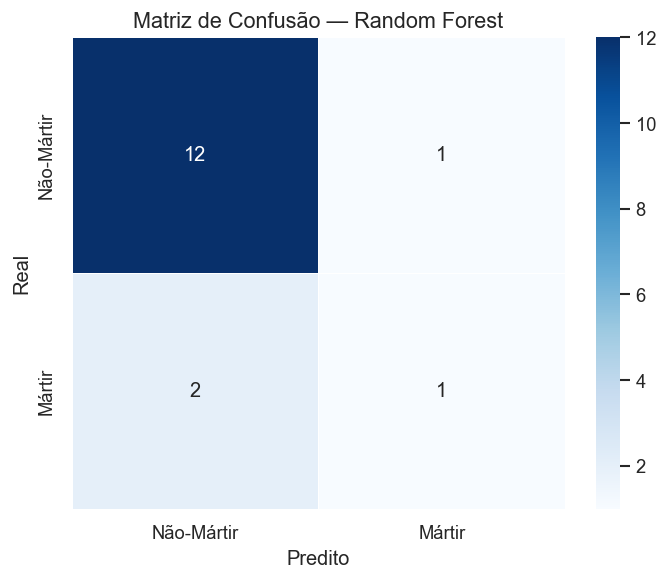


Relatório completo:
              precision    recall  f1-score   support

  Não-Mártir       0.86      0.92      0.89        13
      Mártir       0.50      0.33      0.40         3

    accuracy                           0.81        16
   macro avg       0.68      0.63      0.64        16
weighted avg       0.79      0.81      0.80        16



In [6]:
rf = modelos_treinados['Random Forest']
y_pred_rf = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Não-Mártir', 'Mártir'],
    yticklabels=['Não-Mártir', 'Mártir'],
    ax=ax, linewidths=0.5
)
ax.set_xlabel('Predito', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('Matriz de Confusão — Random Forest', fontsize=13)

plt.tight_layout()
plt.savefig(FIGS / '05_confusion_matrix.png', bbox_inches='tight')
plt.show()

print('\nRelatório completo:')
print(classification_report(y_test, y_pred_rf, target_names=['Não-Mártir', 'Mártir']))

## 4. ROC Curve e AUC

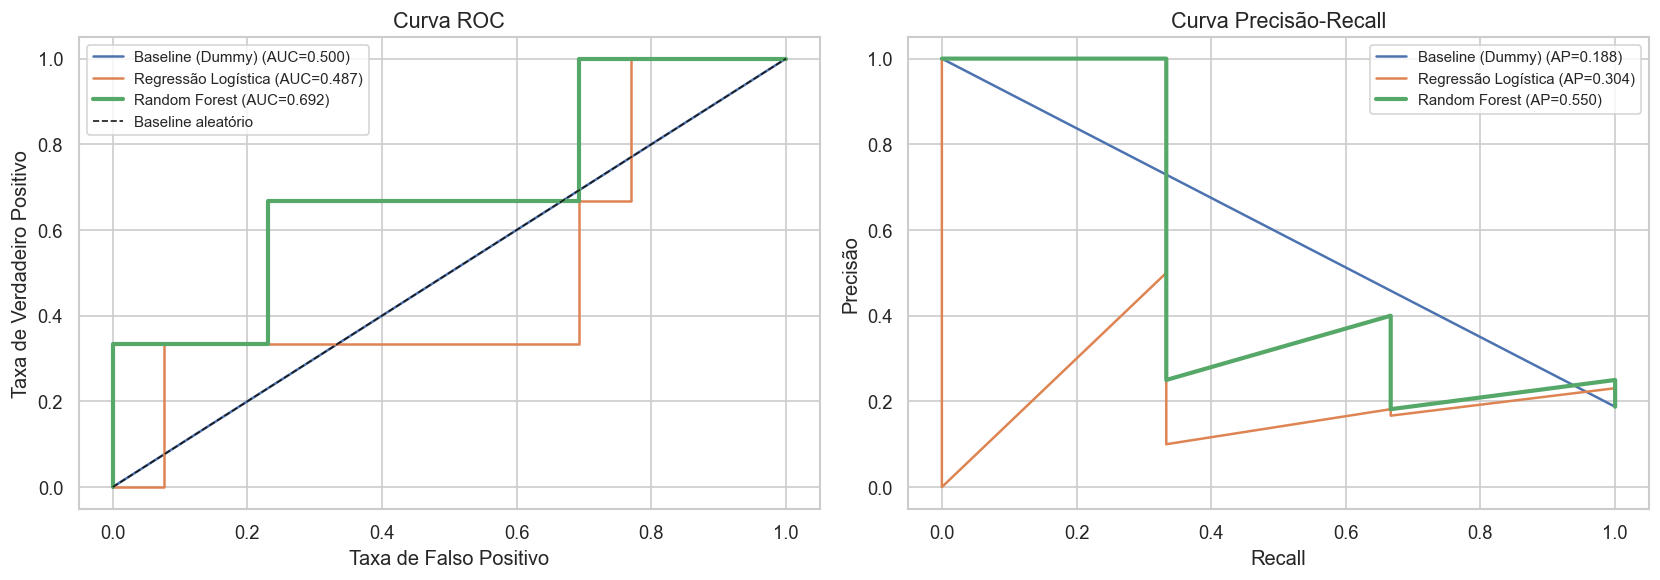

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
for nome, modelo in modelos_treinados.items():
    X_ts = X_test_sc if nome != 'Random Forest' else X_test
    if hasattr(modelo, 'predict_proba'):
        y_prob = modelo.predict_proba(X_ts)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        lw = 2.5 if nome == 'Random Forest' else 1.5
        axes[0].plot(fpr, tpr, lw=lw, label=f'{nome} (AUC={roc_auc:.3f})')

axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Baseline aleatório')
axes[0].set_xlabel('Taxa de Falso Positivo')
axes[0].set_ylabel('Taxa de Verdadeiro Positivo')
axes[0].set_title('Curva ROC', fontsize=13)
axes[0].legend(fontsize=9)

# Precision-Recall
for nome, modelo in modelos_treinados.items():
    X_ts = X_test_sc if nome != 'Random Forest' else X_test
    if hasattr(modelo, 'predict_proba'):
        y_prob = modelo.predict_proba(X_ts)[:, 1]
        prec, rec, _ = precision_recall_curve(y_test, y_prob)
        ap = average_precision_score(y_test, y_prob)
        lw = 2.5 if nome == 'Random Forest' else 1.5
        axes[1].plot(rec, prec, lw=lw, label=f'{nome} (AP={ap:.3f})')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precisão')
axes[1].set_title('Curva Precisão-Recall', fontsize=13)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGS / '05_roc_pr_curves.png', bbox_inches='tight')
plt.show()

## 5. Feature Importance — O Gráfico Central do Random Forest

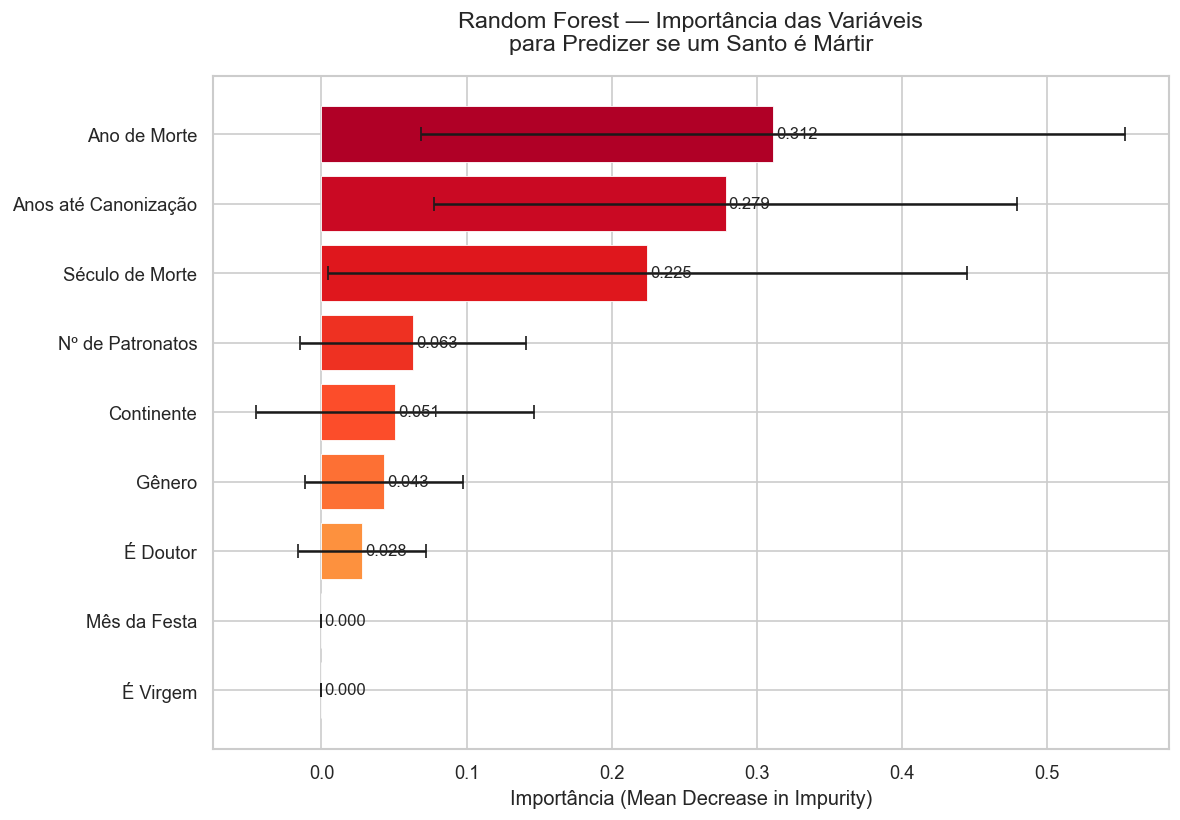

Feature mais importante: Ano de Morte


In [8]:
importancias = rf.feature_importances_
desvios      = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

# Nomes legíveis
nomes_features = {
    'death_year':          'Ano de Morte',
    'century_of_death':    'Século de Morte',
    'years_to_canonization': 'Anos até Canonização',
    'num_patron_topics':   'Nº de Patronatos',
    'feast_month':         'Mês da Festa',
    'is_doctor':           'É Doutor',
    'is_virgin':           'É Virgem',
    'continent_enc':       'Continente',
    'gender_enc':          'Gênero',
}
labels = [nomes_features.get(f, f) for f in features]

# Ordenar por importância
ordem = np.argsort(importancias)

fig, ax = plt.subplots(figsize=(10, 7))
cores_bars = plt.cm.YlOrRd(np.linspace(0.35, 0.9, len(ordem)))
bars = ax.barh(
    np.array(labels)[ordem], importancias[ordem],
    xerr=desvios[ordem], color=cores_bars,
    capsize=4, edgecolor='white', linewidth=0.5
)

ax.set_xlabel('Importância (Mean Decrease in Impurity)', fontsize=12)
ax.set_title('Random Forest — Importância das Variáveis\npara Predizer se um Santo é Mártir', fontsize=14, pad=15)

# Rótulos de valor
for bar, imp in zip(bars, importancias[ordem]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{imp:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(FIGS / '05_feature_importance.png', bbox_inches='tight')
plt.show()
print('Feature mais importante:', labels[np.argmax(importancias)])

## 6. Validação Cruzada

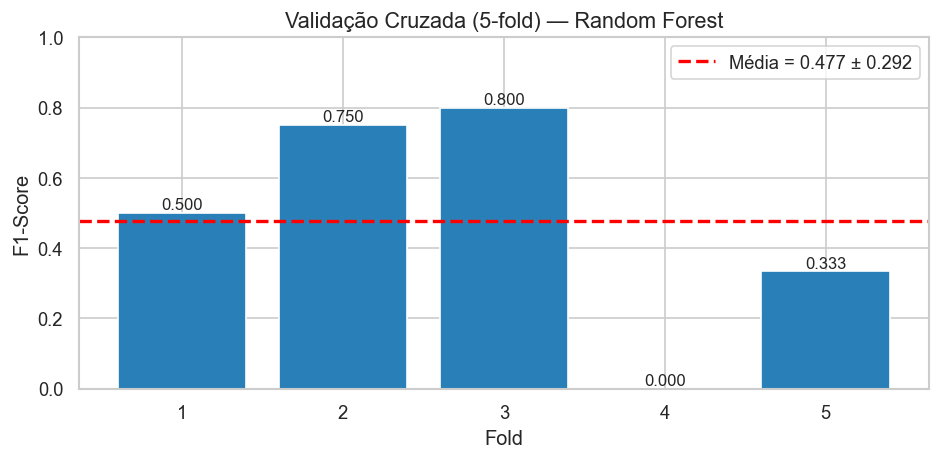

In [9]:
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='f1')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 6), cv_scores, color='#2980B9', edgecolor='white')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', lw=2,
           label=f'Média = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
ax.set_xlabel('Fold')
ax.set_ylabel('F1-Score')
ax.set_title('Validação Cruzada (5-fold) — Random Forest', fontsize=13)
ax.legend()
ax.set_ylim(0, 1)
ax.set_xticks(range(1, 6))

for i, v in enumerate(cv_scores):
    ax.text(i + 1, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(FIGS / '05_cross_validation.png', bbox_inches='tight')
plt.show()

## 7. Curva de Aprendizado

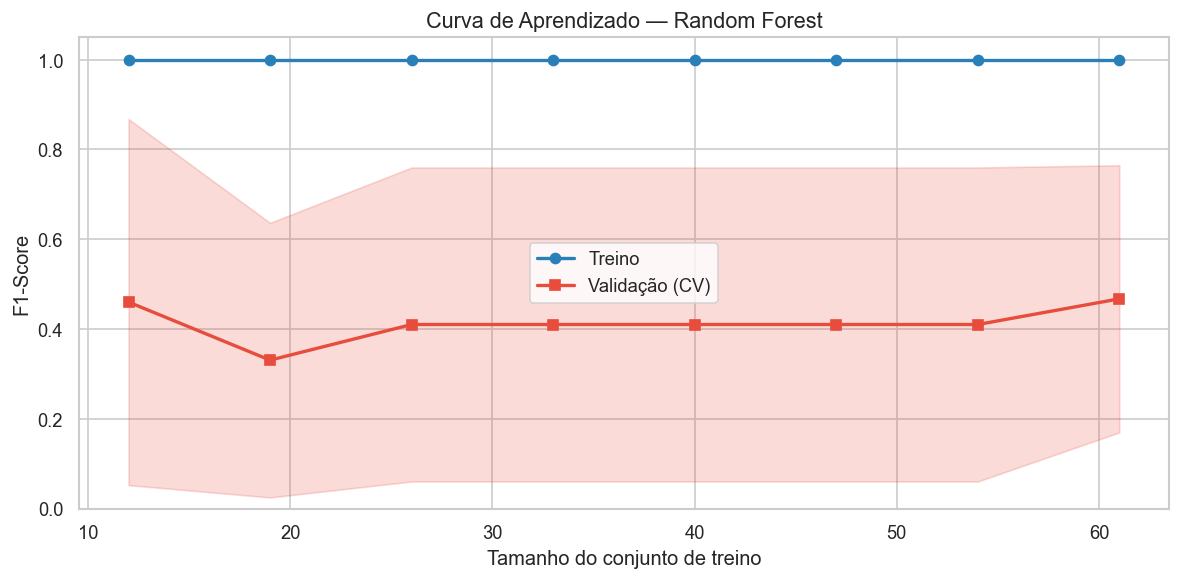

In [10]:
train_sizes, train_scores, val_scores = learning_curve(
    rf, X, y,
    cv=5, scoring='f1',
    train_sizes=np.linspace(0.2, 1.0, 8),
    random_state=42, n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#2980B9', label='Treino', lw=2)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#2980B9')
ax.plot(train_sizes, val_mean, 's-', color='#E74C3C', label='Validação (CV)', lw=2)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='#E74C3C')

ax.set_xlabel('Tamanho do conjunto de treino')
ax.set_ylabel('F1-Score')
ax.set_title('Curva de Aprendizado — Random Forest', fontsize=13)
ax.legend()
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(FIGS / '05_learning_curve.png', bbox_inches='tight')
plt.show()

## 8. SHAP — Explicabilidade Avançada (opcional)

<Figure size 1200x720 with 0 Axes>

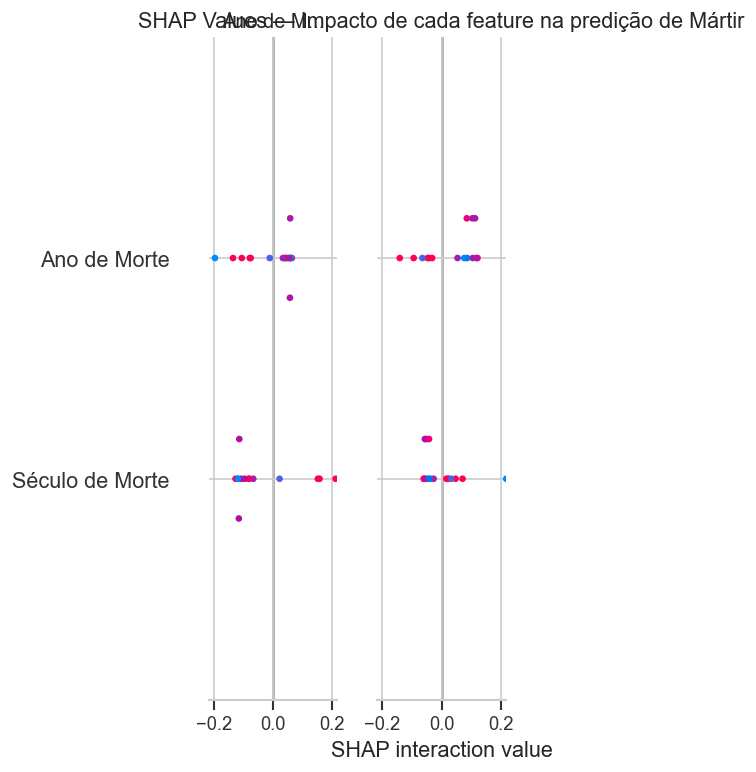

SHAP gerado!


In [11]:
try:
    import shap

    explainer  = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test)

    # Para classificação binária, shap_values é lista [classe0, classe1]
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        sv, X_test,
        feature_names=labels,
        show=False, plot_type='dot'
    )
    plt.title('SHAP Values — Impacto de cada feature na predição de Mártir', fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGS / '05_shap_summary.png', bbox_inches='tight')
    plt.show()
    print('SHAP gerado!')

except ImportError:
    print('SHAP não instalado. Execute: pip install shap')
except Exception as e:
    print(f'Erro ao gerar SHAP: {e}')

## 9. Salvar Modelos

In [12]:
with open(MODELS / 'random_forest_santos.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open(MODELS / 'scaler_classificacao.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Salvar lista de features
with open(MODELS / 'features_classificacao.txt', 'w') as f:
    f.write('\n'.join(features))

print('Modelos salvos!')
print(f'  random_forest_santos.pkl')
print(f'  scaler_classificacao.pkl')
print(f'  features_classificacao.txt')

Modelos salvos!
  random_forest_santos.pkl
  scaler_classificacao.pkl
  features_classificacao.txt


## Próximo Passo

Abra o **Notebook 06 — NLP** para analisar os textos e resumos dos santos com técnicas de processamento de linguagem natural.